# Exploratory Data Analysis — Curriculum & IT Job Market Datasets

**Purpose:** assess dataset scope, comparability, and text quality before skill extraction.

**What this notebook now focuses on:**
- curriculum balance and text-richness asymmetry across universities
- broad vs. IT-only job-market scope after filtering
- source/platform concentration and company concentration
- IT role composition, seniority mix, and posting-date coverage
- validation readiness (`skills_tags` availability)
- cross-corpus comparability for downstream NLP

**Inputs:**
- `data/processed/university/final_curriculum_dataset.csv`
- `data/processed/jobs/final_jobs_dataset.csv`
- `data/processed/jobs/final_jobs_dataset_it_only.csv`
- `data/processed/jobs/it_job_filter_audit.csv` (if available)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CURR_PATH = ROOT / 'data/processed/university/final_curriculum_dataset.csv'
JOBS_ALL_PATH = ROOT / 'data/processed/jobs/final_jobs_dataset.csv'
JOBS_IT_PATH = ROOT / 'data/processed/jobs/final_jobs_dataset_it_only.csv'
AUDIT_PATH = ROOT / 'data/processed/jobs/it_job_filter_audit.csv'

curr = pd.read_csv(CURR_PATH)
jobs_all = pd.read_csv(JOBS_ALL_PATH)
jobs_it = pd.read_csv(JOBS_IT_PATH)
audit = pd.read_csv(AUDIT_PATH) if AUDIT_PATH.exists() else None

for df in [curr, jobs_all, jobs_it]:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('').astype(str)

curr['credits'] = pd.to_numeric(curr.get('credits', np.nan), errors='coerce')
curr['semester'] = pd.to_numeric(curr.get('semester', np.nan), errors='coerce')

curr['has_description'] = curr['description'].str.strip().ne('')
curr['course_text_en'] = curr['course_name'].str.strip()
curr.loc[curr['has_description'], 'course_text_en'] = (
    curr.loc[curr['has_description'], 'course_name'].str.strip()
    + '. '
    + curr.loc[curr['has_description'], 'description'].str.strip()
)
curr['course_word_count'] = curr['course_text_en'].str.split().str.len()

jobs_all['job_word_count'] = jobs_all['full_text'].str.split().str.len()
jobs_it['job_word_count'] = jobs_it['full_text'].str.split().str.len()

for df in [jobs_all, jobs_it]:
    df['posting_date_dt'] = pd.to_datetime(df['posting_date'], errors='coerce')
    df['posting_week'] = df['posting_date_dt'].dt.to_period('W').astype(str)
    df['posting_month'] = df['posting_date_dt'].dt.to_period('M').astype(str)
    df['has_skills_tags'] = df['skills_tags'].str.strip().ne('')

print(f'Curriculum rows:      {len(curr):,}')
print(f'Broad jobs rows:      {len(jobs_all):,}')
print(f'IT-only jobs rows:    {len(jobs_it):,}')
if audit is not None:
    print(f'Filter audit rows:    {len(audit):,}')


Curriculum rows:      1,161
Broad jobs rows:      1,369
IT-only jobs rows:    753
Filter audit rows:    1,369


---
## Part 1. Dataset Snapshot


In [2]:
snapshot = pd.DataFrame([
    {
        'dataset': 'Curriculum (translated)',
        'rows': len(curr),
        'unique_programs': curr['program_name'].nunique(),
        'unique_organizations': curr['university'].nunique(),
        'median_words': round(curr['course_word_count'].median(), 1),
        'text_threshold': '< 10 words',
        'below_threshold': int((curr['course_word_count'] < 10).sum()),
    },
    {
        'dataset': 'Jobs (broad merged)',
        'rows': len(jobs_all),
        'unique_programs': np.nan,
        'unique_organizations': jobs_all['company_name'].nunique(),
        'median_words': round(jobs_all['job_word_count'].median(), 1),
        'text_threshold': '< 50 words',
        'below_threshold': int((jobs_all['job_word_count'] < 50).sum()),
    },
    {
        'dataset': 'Jobs (IT-only filtered)',
        'rows': len(jobs_it),
        'unique_programs': np.nan,
        'unique_organizations': jobs_it['company_name'].nunique(),
        'median_words': round(jobs_it['job_word_count'].median(), 1),
        'text_threshold': '< 50 words',
        'below_threshold': int((jobs_it['job_word_count'] < 50).sum()),
    },
])

display(snapshot)

if audit is not None:
    decision = audit['it_filter_decision'].value_counts().rename_axis('decision').reset_index(name='count')
    decision['share_%'] = (decision['count'] / len(audit) * 100).round(1)
    print('IT filter outcomes:')
    display(decision)


,dataset,rows,unique_programs,unique_organizations,median_words,text_threshold,below_threshold
0,Curriculum (translated),1161,25.0,4,39.0,< 10 words,226
1,Jobs (broad merged),1369,NaN,318,390.0,< 50 words,2
2,Jobs (IT-only filtered),753,NaN,184,407.0,< 50 words,1


IT filter outcomes:


,decision,count,share_%
0,keep,753,55.0
1,drop,558,40.8
2,review,58,4.2


---
## Part 2. Curriculum Scope and Text Richness


In [3]:
uni_summary = (
    curr.groupby('university')
        .agg(
            courses=('course_id', 'count'),
            programs=('program_name', 'nunique'),
            bachelor_courses=('degree_level', lambda s: (s == 'Bachelor').sum()),
            master_courses=('degree_level', lambda s: (s == 'Master').sum()),
            description_pct=('has_description', lambda s: round(s.mean() * 100, 1)),
            median_words=('course_word_count', 'median'),
            short_text_pct=('course_word_count', lambda s: round((s < 10).mean() * 100, 1)),
        )
        .sort_values('courses', ascending=False)
)
uni_summary['median_words'] = uni_summary['median_words'].round(1)
print('Curriculum coverage by university:')
display(uni_summary)


Curriculum coverage by university:


,courses,programs,bachelor_courses,master_courses,description_pct,median_words,short_text_pct
university,,,,,,,
Yerevan State University,691,13,460,231,100.0,40.0,0.3
American University of Armenia,249,7,136,86,97.2,81.0,3.2
National University of Architecture and Construction of Armenia,174,4,118,56,0.0,3.0,97.1
Russian-Armenian University,47,1,47,0,0.0,2.0,100.0


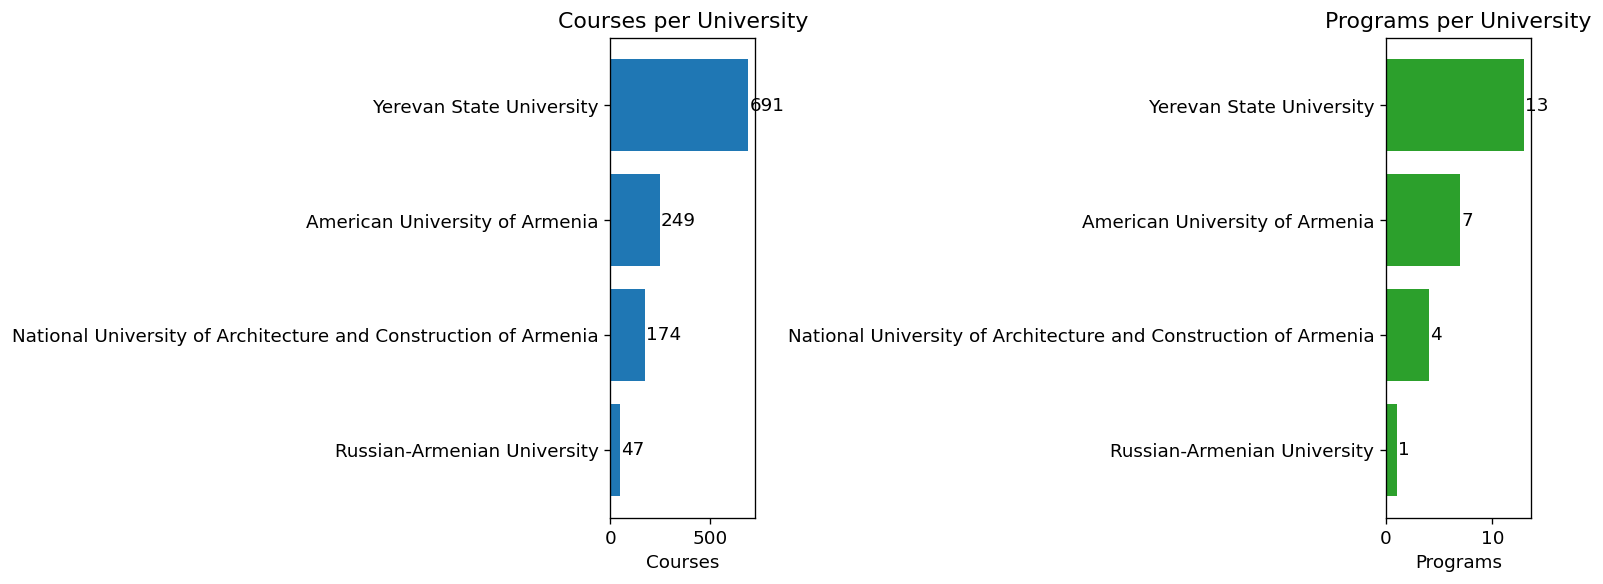

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

course_counts = uni_summary['courses'].sort_values()
program_counts = uni_summary['programs'].sort_values()

bars = axes[0].barh(course_counts.index, course_counts.values, color='#1f77b4')
axes[0].set_title('Courses per University')
axes[0].set_xlabel('Courses')
for bar, val in zip(bars, course_counts.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, int(val), va='center')

bars = axes[1].barh(program_counts.index, program_counts.values, color='#2ca02c')
axes[1].set_title('Programs per University')
axes[1].set_xlabel('Programs')
for bar, val in zip(bars, program_counts.values):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, int(val), va='center')

plt.tight_layout()
plt.show()


Component distribution by university (%):


component,,Elective,General,Mandatory,Other,Professional
university,,,,,,
American University of Armenia,100.0,0.0,0.0,0.0,0.0,0.0
National University of Architecture and Construction of Armenia,100.0,0.0,0.0,0.0,0.0,0.0
Russian-Armenian University,0.0,46.8,0.0,53.2,0.0,0.0
Yerevan State University,0.0,0.0,39.4,0.0,3.3,57.3


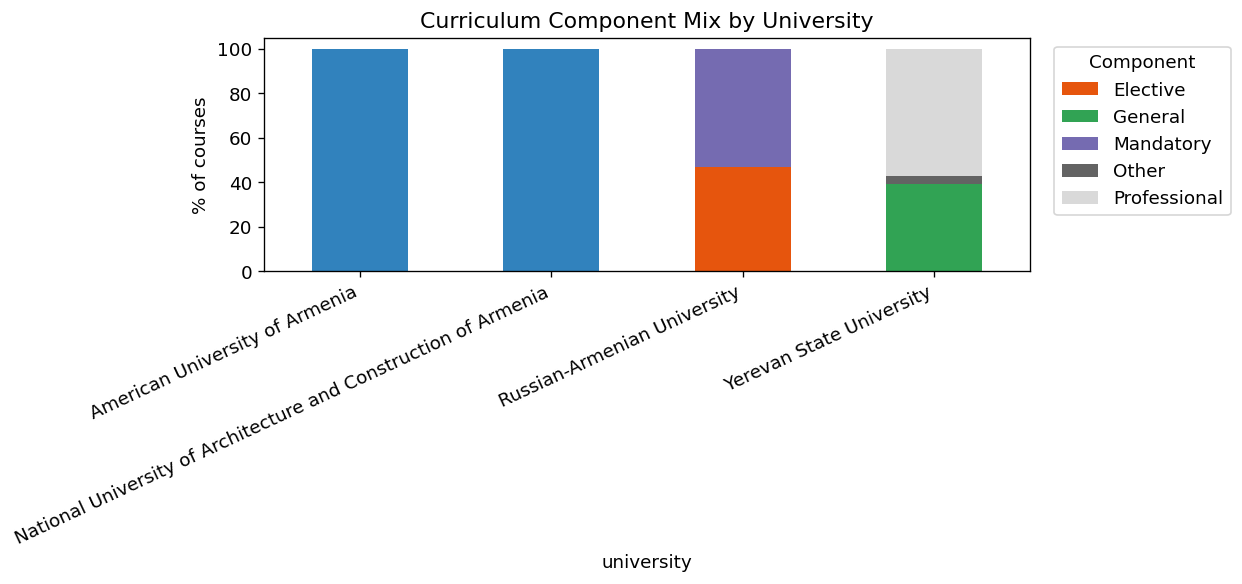

In [5]:
component_ct = pd.crosstab(curr['university'], curr['component'])
component_share = component_ct.div(component_ct.sum(axis=1), axis=0) * 100

print('Component distribution by university (%):')
display(component_share.round(1))

ax = component_share.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20c')
ax.set_title('Curriculum Component Mix by University')
ax.set_ylabel('% of courses')
ax.legend(title='Component', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


Text richness by university:


,median_words,p25_words,p75_words,description_pct
university,,,,
American University of Armenia,81.0,52.0,101.0,97.2
Yerevan State University,40.0,32.0,50.0,100.0
National University of Architecture and Construction of Armenia,3.0,2.0,5.0,0.0
Russian-Armenian University,2.0,2.0,3.5,0.0


/var/folders/0l/7b8_ztcx19d3zxdnsypbsg1r0000gn/T/ipykernel_84508/3672511289.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(word_data, labels=text_summary.index)


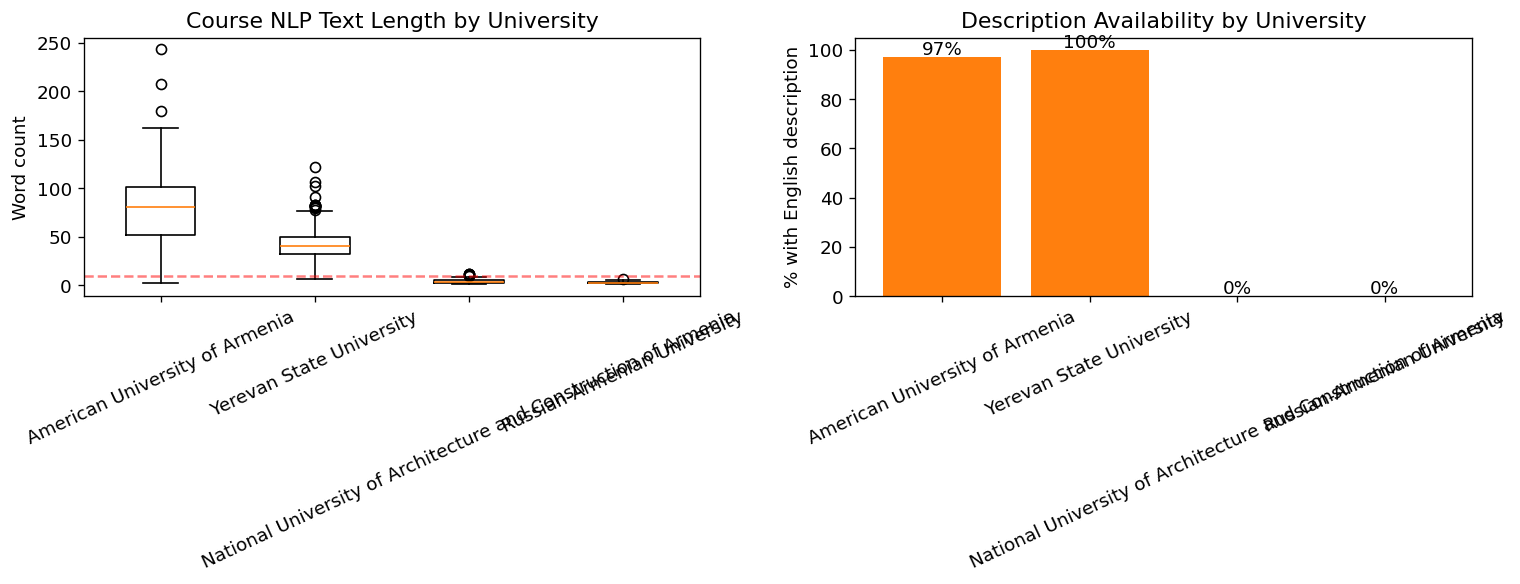

In [6]:
text_summary = (
    curr.groupby('university')
        .agg(
            median_words=('course_word_count', 'median'),
            p25_words=('course_word_count', lambda s: s.quantile(0.25)),
            p75_words=('course_word_count', lambda s: s.quantile(0.75)),
            description_pct=('has_description', lambda s: s.mean() * 100),
        )
        .round(1)
        .sort_values('median_words', ascending=False)
)
print('Text richness by university:')
display(text_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

word_data = [curr.loc[curr['university'] == uni, 'course_word_count'] for uni in text_summary.index]
axes[0].boxplot(word_data, labels=text_summary.index)
axes[0].set_title('Course NLP Text Length by University')
axes[0].set_ylabel('Word count')
axes[0].tick_params(axis='x', rotation=25)
axes[0].axhline(10, color='red', linestyle='--', alpha=0.5)

bars = axes[1].bar(text_summary.index, text_summary['description_pct'], color='#ff7f0e')
axes[1].set_title('Description Availability by University')
axes[1].set_ylabel('% with English description')
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, text_summary['description_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.0f}%', ha='center')

plt.tight_layout()
plt.show()


In [7]:
program_text = (
    curr.groupby(['university', 'program_name'])
        .agg(
            courses=('course_id', 'count'),
            median_words=('course_word_count', 'median'),
            description_pct=('has_description', lambda s: s.mean() * 100),
            short_text_pct=('course_word_count', lambda s: (s < 10).mean() * 100),
        )
        .reset_index()
)

low_info_programs = (
    program_text[
        (program_text['courses'] >= 5)
        & ((program_text['description_pct'] < 40) | (program_text['short_text_pct'] > 50))
    ]
    .sort_values(['short_text_pct', 'description_pct'], ascending=[False, True])
)

print('Programs with low-information NLP text (important for interpretation):')
display(low_info_programs.head(20).round(1))


Programs with low-information NLP text (important for interpretation):


,university,program_name,courses,median_words,description_pct,short_text_pct
11,Russian-Armenian University,Applied Mathematics and Informatics,47,2.0,0.0,100.0
8,National University of Architecture and Constr...,Informatics (Computer Science),76,2.0,0.0,98.7
9,National University of Architecture and Constr...,Information Systems,60,3.0,0.0,96.7
10,National University of Architecture and Constr...,Project Management (in Information Technologies),22,3.5,0.0,95.5
7,National University of Architecture and Constr...,Geographic Information Systems,16,2.0,0.0,93.8


---
## Part 3. Job Market Scope, Filter Impact, and Concentration


In [8]:
job_scope = pd.DataFrame([
    {
        'view': 'Broad merged market',
        'rows': len(jobs_all),
        'sources': jobs_all['source'].nunique(),
        'companies': jobs_all['company_name'].nunique(),
        'median_words': round(jobs_all['job_word_count'].median(), 1),
        'skills_tags_pct': round(jobs_all['has_skills_tags'].mean() * 100, 1),
    },
    {
        'view': 'IT-only market',
        'rows': len(jobs_it),
        'sources': jobs_it['source'].nunique(),
        'companies': jobs_it['company_name'].nunique(),
        'median_words': round(jobs_it['job_word_count'].median(), 1),
        'skills_tags_pct': round(jobs_it['has_skills_tags'].mean() * 100, 1),
    },
])
display(job_scope)

if audit is not None:
    source_keep = (
        audit.groupby(['source', 'it_filter_decision'])
             .size()
             .unstack(fill_value=0)
             .sort_values('keep', ascending=False)
    )
    source_keep['keep_rate_%'] = (source_keep.get('keep', 0) / source_keep.sum(axis=1) * 100).round(1)
    print('IT filter outcomes by source:')
    display(source_keep)


,view,rows,sources,companies,median_words,skills_tags_pct
0,Broad merged market,1369,14,318,390.0,11.8
1,IT-only market,753,13,184,407.0,15.9


IT filter outcomes by source:


it_filter_decision,drop,keep,review,keep_rate_%
source,,,,
linkedin,391,556,45,56.0
epam,31,71,6,65.7
staff.am,4,50,1,90.9
softconstruct,109,37,6,24.3
job.am,10,10,0,50.0
griddynamics,2,9,0,81.8
krisp,1,6,0,85.7
dataart,1,4,0,80.0
nvidia,2,3,0,60.0


Source-level change after IT filtering:


,broad,it_only,keep_rate_%
source,,,
linkedin,992,556,56.0
softconstruct,152,37,24.3
epam,108,71,65.7
staff.am,55,50,90.9
job.am,20,10,50.0
griddynamics,11,9,81.8
krisp,7,6,85.7
10web,5,2,40.0
dataart,5,4,80.0


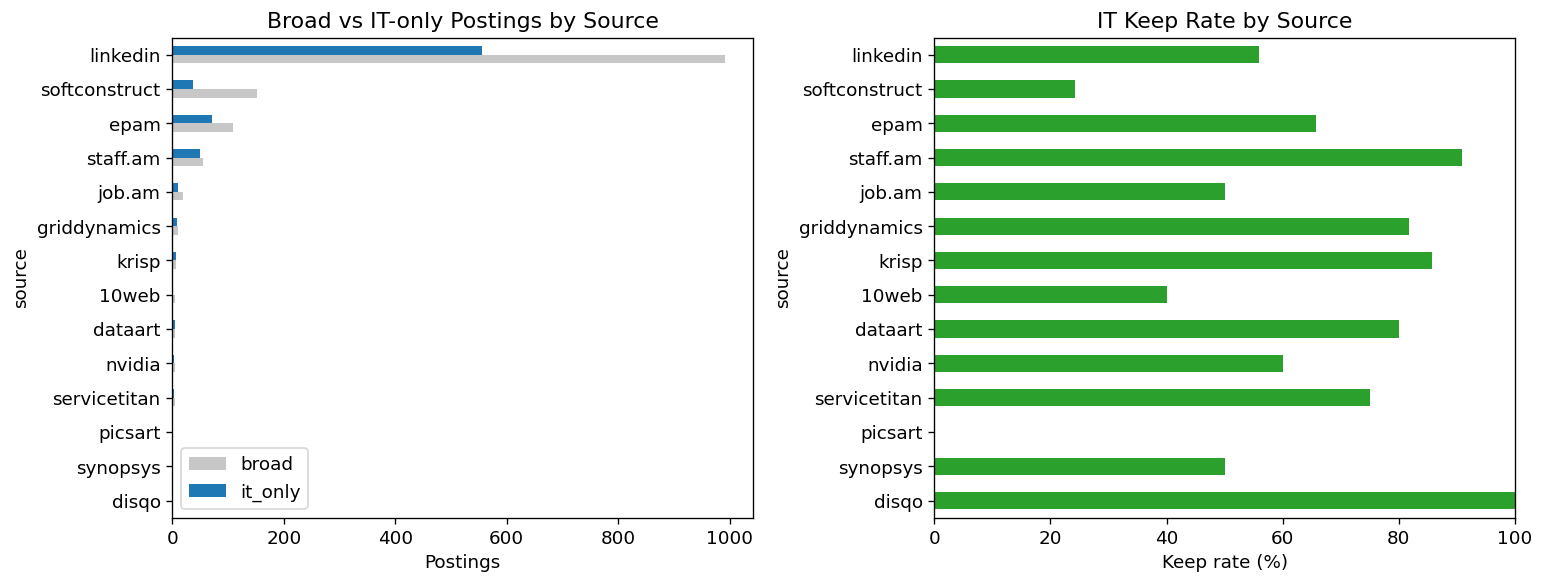

In [9]:
source_compare = pd.DataFrame({
    'broad': jobs_all['source'].value_counts(),
    'it_only': jobs_it['source'].value_counts(),
}).fillna(0).astype(int)
source_compare['keep_rate_%'] = (source_compare['it_only'] / source_compare['broad'] * 100).round(1)
source_compare = source_compare.sort_values('broad', ascending=False)

print('Source-level change after IT filtering:')
display(source_compare)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
source_compare[['broad', 'it_only']].iloc[::-1].plot(kind='barh', ax=axes[0], color=['#c7c7c7', '#1f77b4'])
axes[0].set_title('Broad vs IT-only Postings by Source')
axes[0].set_xlabel('Postings')

source_compare['keep_rate_%'].iloc[::-1].plot(kind='barh', ax=axes[1], color='#2ca02c')
axes[1].set_title('IT Keep Rate by Source')
axes[1].set_xlabel('Keep rate (%)')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()


In [10]:
def concentration_stats(series, top_n=10):
    share = series / series.sum()
    hhi = (share.pow(2).sum() * 10000).round(1)
    top_n_share = (share.head(top_n).sum() * 100).round(1)
    return hhi, top_n_share

company_counts = jobs_it['company_name'].value_counts()
source_counts = jobs_it['source'].value_counts()
company_hhi, top10_company_share = concentration_stats(company_counts, top_n=10)
source_hhi, top5_source_share = concentration_stats(source_counts, top_n=5)

company_table = company_counts.head(20).rename_axis('company').reset_index(name='postings')
company_table['share_%'] = (company_table['postings'] / len(jobs_it) * 100).round(1)
print('Top companies in the IT-only market:')
display(company_table)

print(f'Company concentration (HHI): {company_hhi}')
print(f'Top 10 companies share:      {top10_company_share}%')
print(f'Source concentration (HHI):  {source_hhi}')
print(f'Top 5 sources share:         {top5_source_share}%')
print(f'LinkedIn share (IT-only):    {(jobs_it["source"].eq("linkedin").mean() * 100):.1f}%')
print(f'SoftConstruct share (IT-only): {(jobs_it["company_name"].eq("SoftConstruct").mean() * 100):.1f}%')


Top companies in the IT-only market:


,company,postings,share_%
0,EPAM Systems,203,27.0
1,SoftConstruct,60,8.0
2,Cisco,30,4.0
3,Commit,19,2.5
4,Tabby | تابي,17,2.3
5,Pragmatike,17,2.3
6,Grid Dynamics,15,2.0
7,Reboot Monkey,12,1.6
8,Krisp,12,1.6
9,Intetics,12,1.6


Company concentration (HHI): 856.2
Top 10 companies share:      52.7%
Source concentration (HHI):  5613.7
Top 5 sources share:         96.1%
LinkedIn share (IT-only):    73.8%
SoftConstruct share (IT-only): 8.0%


---
## Part 4. IT Job Market Structure


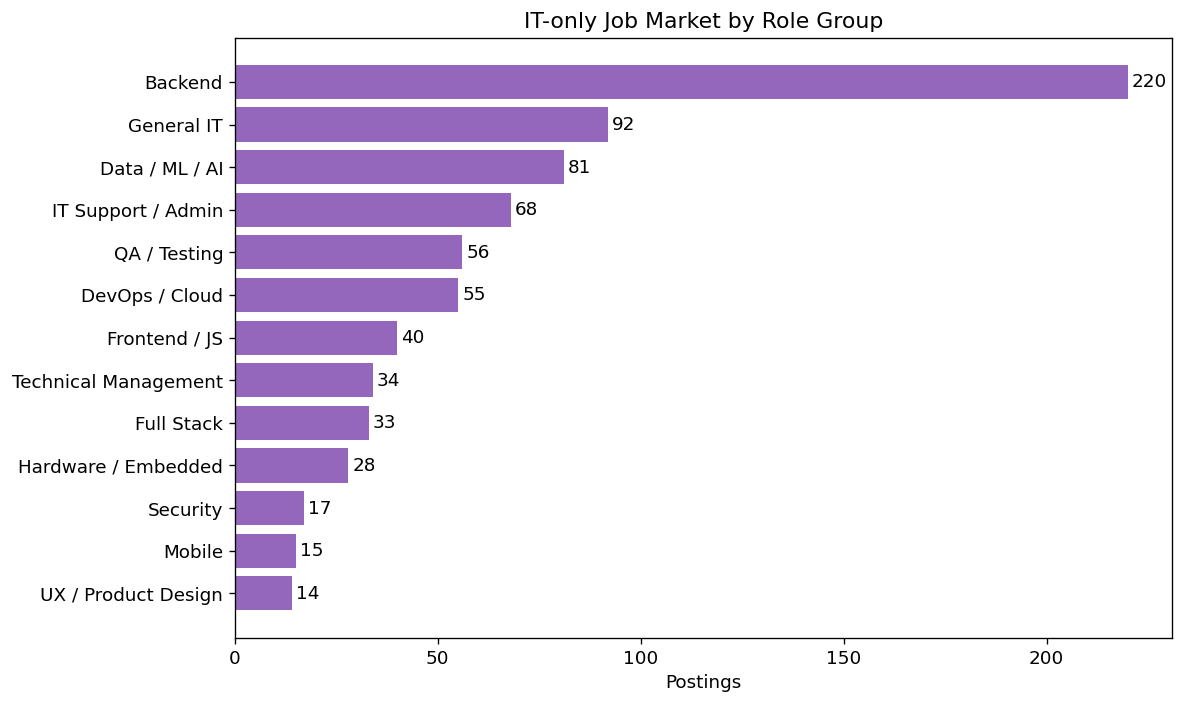

Role distribution (% of IT-only jobs):


,share_%
it_role_group,
UX / Product Design,1.9
Mobile,2.0
Security,2.3
Hardware / Embedded,3.7
Full Stack,4.4
Technical Management,4.5
Frontend / JS,5.3
DevOps / Cloud,7.3
QA / Testing,7.4


In [11]:
role_counts = jobs_it['it_role_group'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(role_counts.index, role_counts.values, color='#9467bd')
ax.set_title('IT-only Job Market by Role Group')
ax.set_xlabel('Postings')
for bar, val in zip(bars, role_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, int(val), va='center')
plt.tight_layout()
plt.show()

role_share = (role_counts / len(jobs_it) * 100).round(1)
print('Role distribution (% of IT-only jobs):')
display(role_share.rename('share_%').to_frame())


Role × seniority table:


seniority_level,,Associate,Associate Management,Chief,Director,Entry level,Executive,Internship,Junior,Lead,Mid,Mid level,"Mid level, Senior",Mid-Senior level,Middle,Middle Management,Not Applicable,Not defined,"Not required, Junior",Principal,Senior
it_role_group,,,,,,,,,,,,,,,,,,,,,
Backend,15,1,1,0,2,7,0,1,1,5,0,10,1,107,0,2,28,3,0,2,34
General IT,1,5,4,0,0,3,0,23,2,6,1,4,0,30,0,0,4,0,0,0,9
Data / ML / AI,6,1,0,0,0,6,0,0,0,4,1,1,0,35,0,1,12,0,0,0,14
IT Support / Admin,12,1,0,0,0,26,0,0,0,1,0,2,1,16,1,0,3,0,0,0,5
QA / Testing,4,1,0,0,1,9,0,15,3,0,0,2,0,17,0,0,4,0,0,0,0
DevOps / Cloud,2,1,0,1,0,1,1,7,0,0,0,1,0,29,1,0,6,0,0,1,4
Frontend / JS,2,0,0,0,0,0,0,7,0,0,0,3,0,10,0,0,7,3,1,0,7
Technical Management,2,4,4,0,1,0,0,0,0,2,0,0,0,13,0,2,5,0,0,0,1
Full Stack,0,0,0,0,0,1,0,0,0,1,0,2,0,19,0,0,5,0,0,0,5


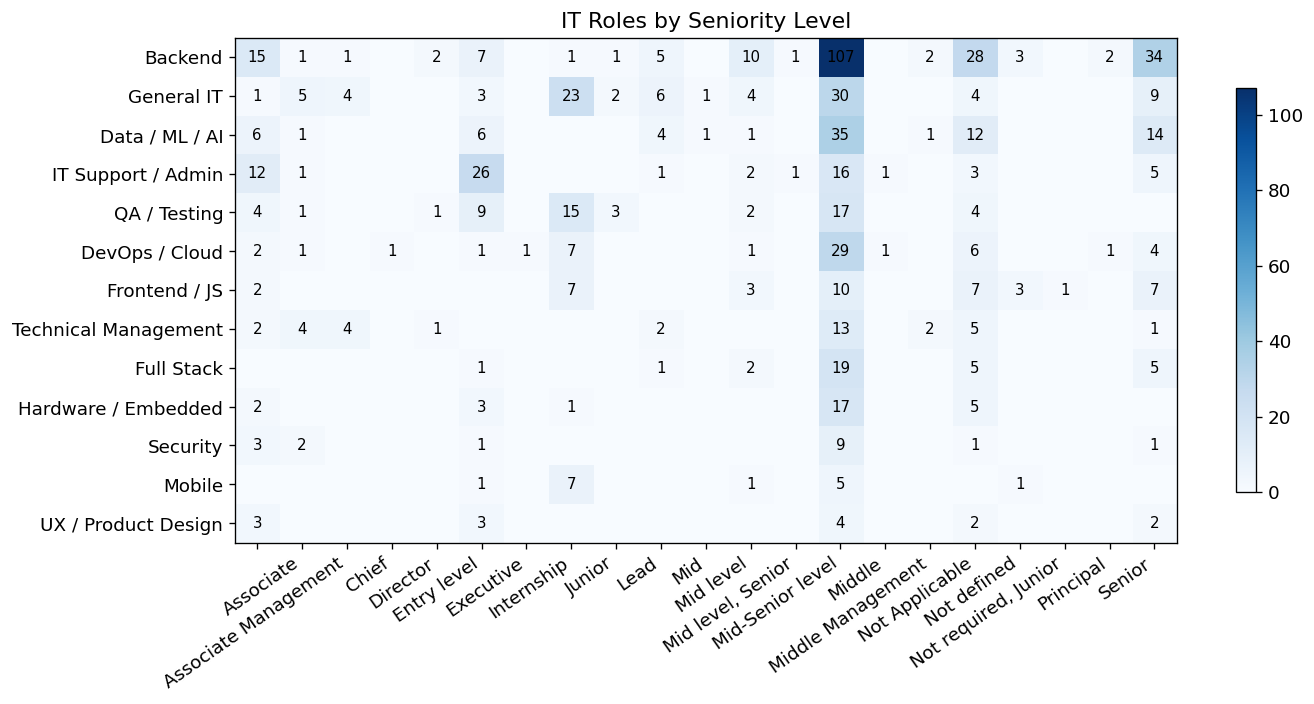

In [12]:
role_seniority = pd.crosstab(jobs_it['it_role_group'], jobs_it['seniority_level'])
role_seniority = role_seniority.loc[role_counts.index[::-1]]

print('Role × seniority table:')
display(role_seniority)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(role_seniority.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(role_seniority.shape[1]))
ax.set_xticklabels(role_seniority.columns, rotation=35, ha='right')
ax.set_yticks(range(role_seniority.shape[0]))
ax.set_yticklabels(role_seniority.index)
for i in range(role_seniority.shape[0]):
    for j in range(role_seniority.shape[1]):
        value = role_seniority.iloc[i, j]
        if value:
            ax.text(j, i, int(value), ha='center', va='center', fontsize=9)
ax.set_title('IT Roles by Seniority Level')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


Posting month distribution:


,postings
posting_month,
2025-04,1
2025-06,3
2025-07,5
2025-08,4
2025-09,7
2025-10,14
2025-11,16
2025-12,15
2026-01,37


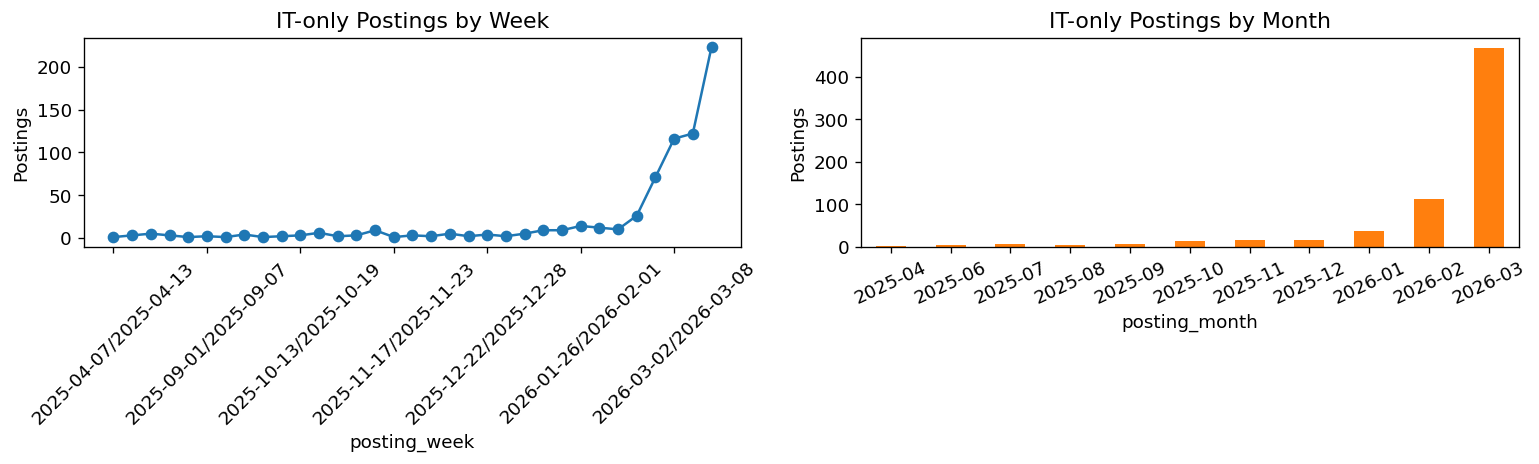

In [13]:
weekly = jobs_it.dropna(subset=['posting_date_dt']).groupby('posting_week').size()
monthly = jobs_it.dropna(subset=['posting_date_dt']).groupby('posting_month').size()

print('Posting month distribution:')
display(monthly.rename('postings').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
weekly.plot(ax=axes[0], marker='o', color='#1f77b4')
axes[0].set_title('IT-only Postings by Week')
axes[0].set_ylabel('Postings')
axes[0].tick_params(axis='x', rotation=45)

monthly.plot(kind='bar', ax=axes[1], color='#ff7f0e')
axes[1].set_title('IT-only Postings by Month')
axes[1].set_ylabel('Postings')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


Role-level NLP input quality and validation readiness:


,postings,median_words,p25_words,p75_words,skills_tags_pct
it_role_group,,,,,
Backend,220,411.5,266.5,502.5,20.9
General IT,92,394.0,318.0,480.5,20.7
Data / ML / AI,81,435.0,345.0,611.0,14.8
IT Support / Admin,68,373.0,236.0,546.0,7.4
QA / Testing,56,309.0,289.0,407.2,7.1
DevOps / Cloud,55,491.0,334.0,577.5,12.7
Frontend / JS,40,312.5,235.2,344.0,30.0
Technical Management,34,528.5,368.0,598.5,17.6
Full Stack,33,465.0,350.0,544.0,18.2


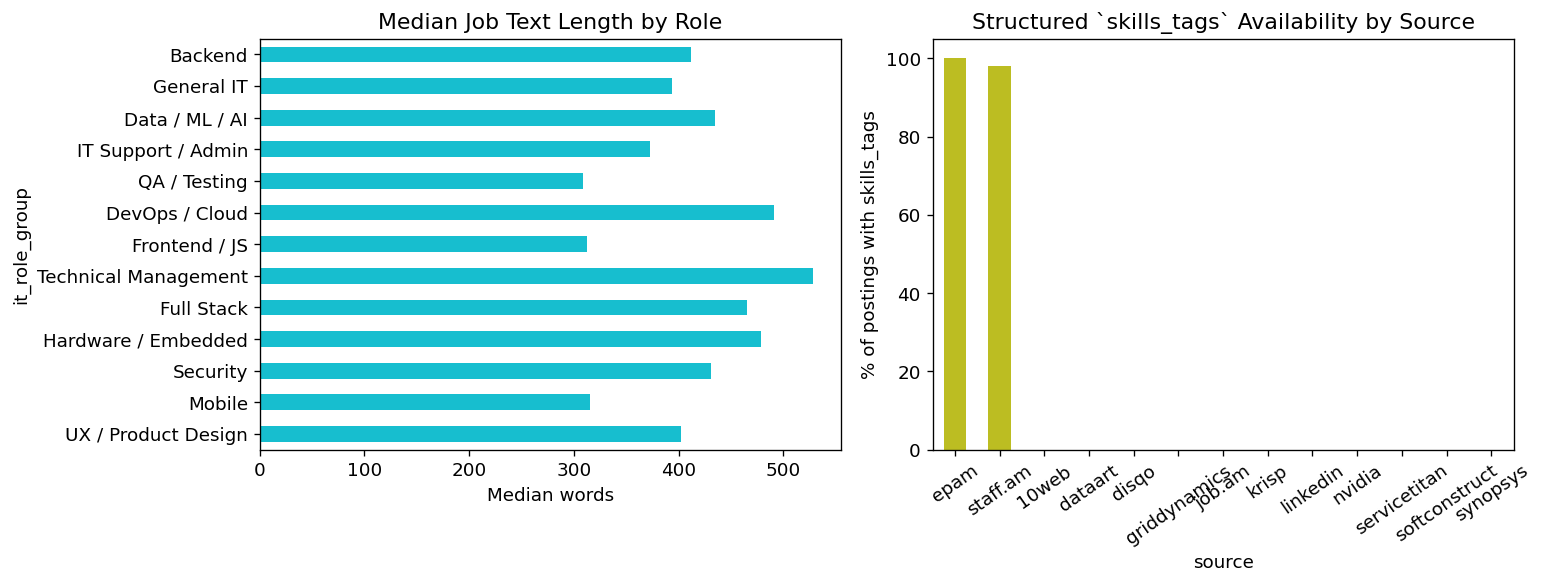

In [14]:
role_text = (
    jobs_it.groupby('it_role_group')
           .agg(
               postings=('job_title', 'count'),
               median_words=('job_word_count', 'median'),
               p25_words=('job_word_count', lambda s: s.quantile(0.25)),
               p75_words=('job_word_count', lambda s: s.quantile(0.75)),
               skills_tags_pct=('has_skills_tags', lambda s: s.mean() * 100),
           )
           .round(1)
           .sort_values('postings', ascending=False)
)
print('Role-level NLP input quality and validation readiness:')
display(role_text)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
role_text['median_words'].iloc[::-1].plot(kind='barh', ax=axes[0], color='#17becf')
axes[0].set_title('Median Job Text Length by Role')
axes[0].set_xlabel('Median words')

skills_by_source = (
    jobs_it.groupby('source')['has_skills_tags']
           .mean()
           .sort_values(ascending=False)
           .mul(100)
           .round(1)
)
skills_by_source.plot(kind='bar', ax=axes[1], color='#bcbd22')
axes[1].set_title('Structured `skills_tags` Availability by Source')
axes[1].set_ylabel('% of postings with skills_tags')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


---
## Part 5. Cross-Corpus Comparability for NLP


In [15]:
comparison = pd.DataFrame([
    {
        'corpus': 'Curriculum',
        'rows': len(curr),
        'median_words': round(curr['course_word_count'].median(), 1),
        'p25_words': round(curr['course_word_count'].quantile(0.25), 1),
        'p75_words': round(curr['course_word_count'].quantile(0.75), 1),
        'short_text_share_%': round((curr['course_word_count'] < 10).mean() * 100, 1),
    },
    {
        'corpus': 'IT-only jobs',
        'rows': len(jobs_it),
        'median_words': round(jobs_it['job_word_count'].median(), 1),
        'p25_words': round(jobs_it['job_word_count'].quantile(0.25), 1),
        'p75_words': round(jobs_it['job_word_count'].quantile(0.75), 1),
        'short_text_share_%': round((jobs_it['job_word_count'] < 50).mean() * 100, 1),
    },
])
print('Corpus-level comparability summary:')
display(comparison)


Corpus-level comparability summary:


,corpus,rows,median_words,p25_words,p75_words,short_text_share_%
0,Curriculum,1161,39.0,21.0,55.0,19.5
1,IT-only jobs,753,407.0,289.0,531.0,0.1


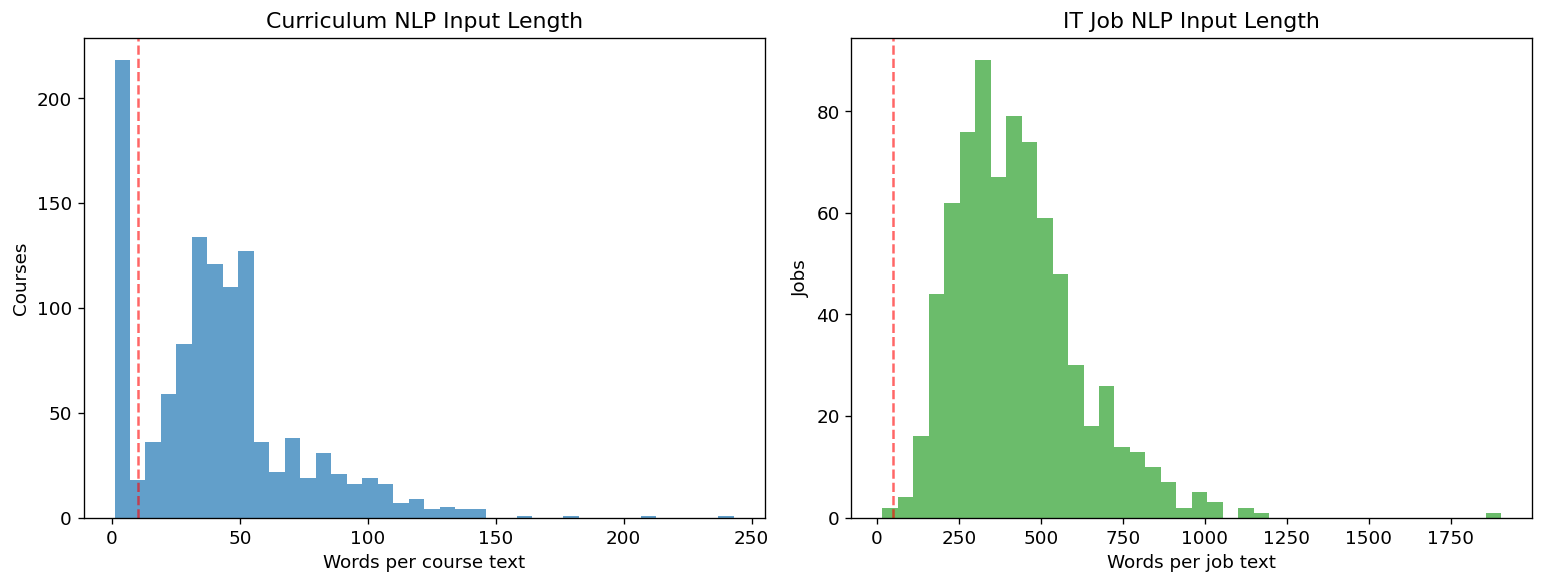

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(curr['course_word_count'], bins=40, alpha=0.7, color='#1f77b4')
axes[0].axvline(10, color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Curriculum NLP Input Length')
axes[0].set_xlabel('Words per course text')
axes[0].set_ylabel('Courses')

axes[1].hist(jobs_it['job_word_count'], bins=40, alpha=0.7, color='#2ca02c')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('IT Job NLP Input Length')
axes[1].set_xlabel('Words per job text')
axes[1].set_ylabel('Jobs')

plt.tight_layout()
plt.show()


In [17]:
short_courses = curr[curr['course_word_count'] < 10].groupby('university').size().rename('short_courses')
short_jobs = jobs_it[jobs_it['job_word_count'] < 50].groupby('source').size().rename('short_jobs')

print('Short-text curriculum concentration (university level):')
display(short_courses.to_frame())

print('Short-text IT jobs by source:')
display(short_jobs.to_frame().sort_values('short_jobs', ascending=False))


Short-text curriculum concentration (university level):


,short_courses
university,
American University of Armenia,8
National University of Architecture and Construction of Armenia,169
Russian-Armenian University,47
Yerevan State University,2


Short-text IT jobs by source:


,short_jobs
source,
softconstruct,1


---
## Part 6. EDA Takeaways for the Thesis


In [18]:
linked_share = jobs_it['source'].eq('linkedin').mean() * 100
softconstruct_share = jobs_it['company_name'].eq('SoftConstruct').mean() * 100
curr_desc_pct = curr['has_description'].mean() * 100
curr_short_pct = (curr['course_word_count'] < 10).mean() * 100
jobs_short_pct = (jobs_it['job_word_count'] < 50).mean() * 100

print('1. Curriculum coverage is structurally uneven across universities.')
print('   Programs with weak description coverage should be interpreted as lower-bound estimates.')
print()
print('2. The IT-only filter materially narrows the market corpus before skill extraction.')
print(f'   Broad jobs: {len(jobs_all):,} -> IT-only jobs: {len(jobs_it):,}.')
if audit is not None:
    print(f'   Review queue remains: {(audit["it_filter_decision"] == "review").sum():,} ambiguous postings.')
print()
print('3. The demand side is concentrated and that should be discussed explicitly.')
print(f'   LinkedIn share in IT-only jobs: {linked_share:.1f}%. SoftConstruct share: {softconstruct_share:.1f}%.')
print()
print('4. Text asymmetry remains a core methodological issue.')
print(f'   Curriculum with English descriptions: {curr_desc_pct:.1f}%. Short curriculum texts: {curr_short_pct:.1f}%.')
print(f'   Short IT job texts (<50 words): {jobs_short_pct:.1f}%.')
print()
print('5. The corpus is ready for NLP, but not uniformly rich across all units of comparison.')
print('   This matters when interpreting university rankings, program gaps, and method recall.')


1. Curriculum coverage is structurally uneven across universities.
   Programs with weak description coverage should be interpreted as lower-bound estimates.

2. The IT-only filter materially narrows the market corpus before skill extraction.
   Broad jobs: 1,369 -> IT-only jobs: 753.
   Review queue remains: 58 ambiguous postings.

3. The demand side is concentrated and that should be discussed explicitly.
   LinkedIn share in IT-only jobs: 73.8%. SoftConstruct share: 8.0%.

4. Text asymmetry remains a core methodological issue.
   Curriculum with English descriptions: 80.4%. Short curriculum texts: 19.5%.
   Short IT job texts (<50 words): 0.1%.

5. The corpus is ready for NLP, but not uniformly rich across all units of comparison.
   This matters when interpreting university rankings, program gaps, and method recall.
